# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Raj Bhowmic

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [19]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [20]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [21]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
26,it,6
63,what,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [34]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,5348.0
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,5240.0
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4451.0
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,4050.0
3029,TRRSNPA128F148C45E,SOIUOEW12A67021D3D,AR8RXRI1187FB4104B,The Roots,Mellow My Man,From The Ground Up,0,288.31302,0.862795,0.600282,hip hop,Hip-Hop; jazzy; the roots; rap; hip hop,886,270,117.358425,0,3987.0
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,3964.0
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,3832.0
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,3830.0
5245,TRLTYLK128F92FE6FF,SOWVIEO12AB0182D10,AR03BDP1187FB5B324,Britney Spears,Radar,Radar,2007,353.33179,0.947328,0.607257,pop,pop; dance; Britney Spears; female vocalists; ...,500,96,116.614750,0,3813.0
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,3771.0


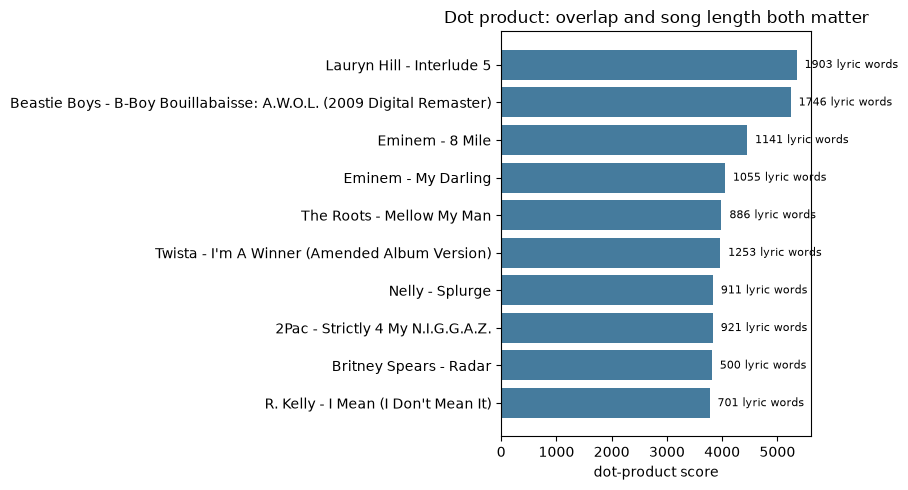

In [35]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

The top matches are influenced by similar words because the higher dot product scores indicate that the songs do share frequent words. Dot product also rewards song size  with longer songs having more words with larger scores as a result that make them seem similar.

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [50]:
results1 = top_40.copy()
for i, row in results1.iterrows():

    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get current top 40 song rather than first song
    query = X[query_idx]
    dot_scores = X @ query

    dot_scores[query_idx] = -np.inf
    top_matches = np.argsort(dot_scores)[-3:][::-1] #Get top 3 non-self matches

    results1.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results1.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results1.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]
    results1.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results1.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results1.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]
    results1.loc[i, "match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results1.loc[i, "match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results1.loc[i, "match_3"] = songs.iloc[top_matches[2]]["song_id"]

results1.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
results1[["song_id", "match_1", "match_1_title", "match_1_word_count", "match_2", "match_2_title", "match_2_word_count", "match_3", "match_3_title", "match_3_word_count"]]
#Used Gen AI in ChatGPT to help in modifying code to display the top 3 matches for each top 40 song

,song_id,match_1,match_1_title,match_1_word_count,match_2,match_2_title,match_2_word_count,match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0,SOXUSKK12A8C144F94,Hot N Cold (Innerpartysystem Main),429.0
1,SOEFNXT12AB017E829,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOCUXGX12A8C13B78C,I Mean (I Don't Mean It),701.0
2,SOVUCRS12A58A7D207,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0
3,SORMDVX12AB01816AA,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOVYGAV12A58A7C3A9,I Want You,617.0
4,SOYTJAC12AF729F49D,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SORMTGC12A6D4F6C8B,Ice Is Workin' It,898.0
556,SOLBZDL12CF5F88BE5,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0
557,SOJFEHH12A6BD546BE,SOONCPO12AF72A1986,Interlude 5,1903.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0
558,SORFOFF12A8C13B65E,SOOHYOB12CF5F87A28,Touch It / Technologic,687.0,SORMTGC12A6D4F6C8B,Ice Is Workin' It,898.0,SOONCPO12AF72A1986,Interlude 5,1903.0


In [52]:
results1 = top_40.copy()
for i, row in results1.iterrows():

    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get current top 40 song rather than first song
    query = TFIDF[query_idx]
    dot_scores = TFIDF @ query

    dot_scores[query_idx] = -np.inf
    top_matches = np.argsort(dot_scores)[-3:][::-1] #Get top 3 non-self matches

    results1.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results1.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results1.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]
    results1.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results1.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results1.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]
    results1.loc[i, "match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results1.loc[i, "match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results1.loc[i, "match_3"] = songs.iloc[top_matches[2]]["song_id"]

results1.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
results1[["song_id", "match_1", "match_1_title", "match_1_word_count", "match_2", "match_2_title", "match_2_word_count", "match_3", "match_3_title", "match_3_word_count"]]

,song_id,match_1,match_1_title,match_1_word_count,match_2,match_2_title,match_2_word_count,match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOVJUBY12A6701FE46,Happy Boys & Girls,477.0,SOKNHPO12A8C1435F9,Angel,448.0,SOPFRMI12A6D4F79D7,Being With You,340.0
1,SOEFNXT12AB017E829,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOUZUFC12A8C14222C,Honest Expression,933.0
2,SOVUCRS12A58A7D207,SOONCPO12AF72A1986,Interlude 5,1903.0,SORAWSB12A6701FBC8,If I Had,736.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0
3,SORMDVX12AB01816AA,SOKSMJD12A6D4F812E,Ear Drums Pop,788.0,SOJZEVI12A58A7648A,1st Booty On Duty,1052.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0
4,SOYTJAC12AF729F49D,SOONCPO12AF72A1986,Interlude 5,1903.0,SOFHEBR12CF5F892C7,Man In The Mirror,1543.0,SOUZUFC12A8C14222C,Honest Expression,933.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOFCVMN12A8C141F62,Club Megamix,749.0
556,SOLBZDL12CF5F88BE5,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOIWGDT12AB018A591,The Hourglass,889.0
557,SOJFEHH12A6BD546BE,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOMEJDK12D0219BB71,8 Mile,1141.0
558,SORFOFF12A8C13B65E,SOONCPO12AF72A1986,Interlude 5,1903.0,SOYSABZ12A58A7CAE3,Tell You Something (Nana's Reprise),612.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0


## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [37]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,4783.12000,5.978900
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,4767.60375,5.959505
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4094.49625,5.118120
3029,TRRSNPA128F148C45E,SOIUOEW12A67021D3D,AR8RXRI1187FB4104B,The Roots,Mellow My Man,From The Ground Up,0,288.31302,0.862795,0.600282,hip hop,Hip-Hop; jazzy; the roots; rap; hip hop,886,270,117.358425,0,3734.87625,4.668595
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,3704.24125,4.630302
5245,TRLTYLK128F92FE6FF,SOWVIEO12AB0182D10,AR03BDP1187FB5B324,Britney Spears,Radar,Radar,2007,353.33179,0.947328,0.607257,pop,pop; dance; Britney Spears; female vocalists; ...,500,96,116.614750,0,3635.32375,4.544155
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,3594.83250,4.493541
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,3565.21250,4.456516
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,3550.71125,4.438389
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,3531.92375,4.414905


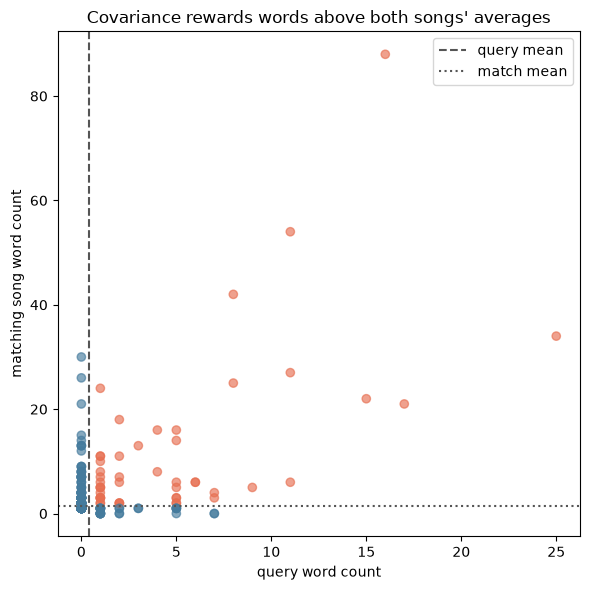

In [38]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

The rankings have changed because the dot product relies more on word counts alone while covariance subtracting the mean reduces influence of song size and common word frequency. The comparison as a result shifts from the overall word count to relative use of words compared to each other when the mean comparison by subtraction. This led to some songs moving either higher or lower in rankings, but some still stay in the same rank as before.

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [53]:
results2 = top_40.copy()
for i, row in results2.iterrows():

    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get current top 40 song rather than first song
    query = X[query_idx]
    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)

    centered_dot_scores = X_centered @ query_centered

    centered_dot_scores[query_idx] = -np.inf
    top_matches = np.argsort(centered_dot_scores)[-3:][::-1] #Get top 3 non-self matches

    results2.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results2.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results2.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]
    results2.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results2.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results2.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]
    results2.loc[i, "covariance_match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results2.loc[i, "covariance_match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results2.loc[i, "covariance_match_3"] = songs.iloc[top_matches[2]]["song_id"]

results2.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
results2[["song_id", "covariance_match_1", "match_1_title", "match_1_word_count", "covariance_match_2", "match_2_title", "match_2_word_count", "covariance_match_3", "match_3_title", "match_3_word_count"]]
#This time, just carried over my code from step 1 and modified it on my own based on previous mentioned functions to replace what step 1 was looking for.

,song_id,covariance_match_1,match_1_title,match_1_word_count,covariance_match_2,match_2_title,match_2_word_count,covariance_match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0,SOXUSKK12A8C144F94,Hot N Cold (Innerpartysystem Main),429.0
1,SOEFNXT12AB017E829,SOCUXGX12A8C13B78C,I Mean (I Don't Mean It),701.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOMEJDK12D0219BB71,8 Mile,1141.0
2,SOVUCRS12A58A7D207,SOONCPO12AF72A1986,Interlude 5,1903.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0
3,SORMDVX12AB01816AA,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOVYGAV12A58A7C3A9,I Want You,617.0
4,SOYTJAC12AF729F49D,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SOONCPO12AF72A1986,Interlude 5,1903.0,SORMTGC12A6D4F6C8B,Ice Is Workin' It,898.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0
556,SOLBZDL12CF5F88BE5,SOONCPO12AF72A1986,Interlude 5,1903.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0
557,SOJFEHH12A6BD546BE,SOONCPO12AF72A1986,Interlude 5,1903.0,SOKHOQG12A8C13EBF2,I'm A Winner (Amended Album Version),1253.0,SOVYGAV12A58A7C3A9,I Want You,617.0
558,SORFOFF12A8C13B65E,SOOHYOB12CF5F87A28,Touch It / Technologic,687.0,SORMTGC12A6D4F6C8B,Ice Is Workin' It,898.0,SOWVWEG12AF72A37C7,It's A Party,832.0


In [54]:
results2 = top_40.copy()
for i, row in results2.iterrows():

    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get current top 40 song rather than first song
    query = TFIDF[query_idx]
    query_centered = query - query.mean()
    TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)

    centered_dot_scores = TFIDF_centered @ query_centered

    centered_dot_scores[query_idx] = -np.inf
    top_matches = np.argsort(centered_dot_scores)[-3:][::-1] #Get top 3 non-self matches

    results2.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results2.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results2.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]
    results2.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results2.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results2.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]
    results2.loc[i, "covariance_match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results2.loc[i, "covariance_match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results2.loc[i, "covariance_match_3"] = songs.iloc[top_matches[2]]["song_id"]

results2.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
results2[["song_id", "covariance_match_1", "match_1_title", "match_1_word_count", "covariance_match_2", "match_2_title", "match_2_word_count", "covariance_match_3", "match_3_title", "match_3_word_count"]]
#This time, just carried over my code from step 1 and modified it on my own based on previous mentioned functions to replace what step 1 was looking for.

,song_id,covariance_match_1,match_1_title,match_1_word_count,covariance_match_2,match_2_title,match_2_word_count,covariance_match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOVJUBY12A6701FE46,Happy Boys & Girls,477.0,SOPFRMI12A6D4F79D7,Being With You,340.0,SOTLPVB12CF5CFD7F3,Baby Be Mine,377.0
1,SOEFNXT12AB017E829,SOSWVVV12A8C13C21C,Fire and Heights,621.0,SOTGYAV12A8C139BF5,Mainstream,863.0,SOFXBUV12AB0187A06,Never Gonna Give You Up,442.0
2,SOVUCRS12A58A7D207,SORAWSB12A6701FBC8,If I Had,736.0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOOKDOU12D0219A1C0,Say Now,609.0
3,SORMDVX12AB01816AA,SOKSMJD12A6D4F812E,Ear Drums Pop,788.0,SOZAKPS12A6D4F7B06,Let's All Get Drunk,623.0,SOJZEVI12A58A7648A,1st Booty On Duty,1052.0
4,SOYTJAC12AF729F49D,SOFHEBR12CF5F892C7,Man In The Mirror,1543.0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOUZUFC12A8C14222C,Honest Expression,933.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SOPFXXX12A6D4F8710,Lentil (Live),316.0,SOFCVMN12A8C141F62,Club Megamix,749.0,SOSTXYN12A6D4F67D4,Passin' Me By,697.0
556,SOLBZDL12CF5F88BE5,SOMGPTZ12A67AE1844,My Story,628.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOELUKE12AF729BF22,The Truth,548.0
557,SOJFEHH12A6BD546BE,SOONCPO12AF72A1986,Interlude 5,1903.0,SOMQGET12A8C133D42,Can't Let Go,437.0,SOJCRPR12A8C135F02,Freezin In The Cold,684.0
558,SORFOFF12A8C13B65E,SOYSABZ12A58A7CAE3,Tell You Something (Nana's Reprise),612.0,SORUOGF12A6D4F878D,Wanna Play,500.0,SOQSJVX12AF72A431B,Oh Jerusalem,692.0


## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [40]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.694141
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.692422
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.682567
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.681100
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.680866
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.677367
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.665229
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.663739
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.663071


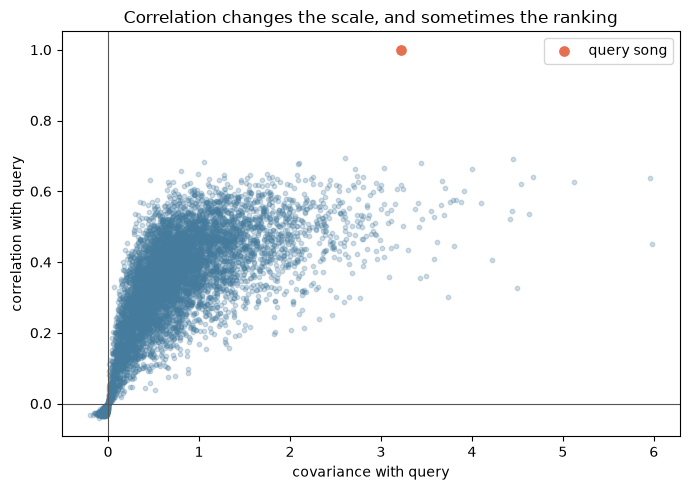

In [41]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

A song with a lower word count has potential to move up in rankings with if the relative word use is similar to before standardization with correlation reducing effects of song size and spread. 

A song could move down in rankings of the higher word count was causing the covariance score to be higher.

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [55]:
results3 = top_40.copy()


for i, row in results3.iterrows():

    
    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get the top 40 songs
    query = X[query_idx]
    query_centered = query - query.mean()
    centered_dot_scores = X_centered @ query_centered
    covariance_scores = centered_dot_scores / X.shape[1]
    X_std = X.std(axis=1)
    query_std = query.std()

    denom = X_std * query_std

    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )

    corr_scores[query_idx] = -np.inf
    top_matches = np.argsort(corr_scores)[-3:][::-1] #Only get the top 3 non-self matches

    results3.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results3.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results3.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]

    results3.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results3.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results3.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]

    results3.loc[i, "correlation_match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results3.loc[i, "correlation_match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results3.loc[i, "correlation_match_3"] = songs.iloc[top_matches[2]]["song_id"]


results3.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

results3[["song_id","correlation_match_1", "match_1_title", "match_1_word_count","correlation_match_2", "match_2_title", "match_2_word_count","correlation_match_3", "match_3_title", "match_3_word_count"]]
#This time, just carried over my code from step 1 and modified it on my own based on previous mentioned functions to replace what step 1 was looking for.

,song_id,correlation_match_1,match_1_title,match_1_word_count,correlation_match_2,match_2_title,match_2_word_count,correlation_match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOBCLJC12D021B0B38,You're All The World To Me,145.0,SOMTNQR12A8C13FE21,You're The Top,183.0,SOEDEUM12A8C13EEBB,You're A Soldier,161.0
1,SOEFNXT12AB017E829,SOLKHDS12A8159E9AA,Plastic World,282.0,SOYWPDR12A8C13CEF0,The Ups And Downs,265.0,SOKRKJD12A8C13C4AC,Keep Moving,660.0
2,SOVUCRS12A58A7D207,SOGVLHO12A8AE48809,Preacher On A Sunday Morning,544.0,SOSCXNJ12AB017B875,Ready For The Weekend,390.0,SONFHQQ12A8C132784,Beyond Salvation,108.0
3,SORMDVX12AB01816AA,SOEAKDX12A8AE48FD9,All I Do,215.0,SOBTWBZ12A6D4FBE3E,Overjoyed,243.0,SOBOHKS12A67AD72E3,Day And Night,352.0
4,SOYTJAC12AF729F49D,SOMPUQO12A8C13A574,Hook,378.0,SOLYAYO12A8C13C04D,I Don't Want To Talk About It,549.0,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SORTVLM12A8C13A5FF,It's Your World,236.0,SOTWYRA12A8C138A7B,Trans DF Express,601.0,SOFJSZH12A6D4F5ED3,Physical Stamina,417.0
556,SOLBZDL12CF5F88BE5,SOELHJS12A6D4F8EDE,Closer To You,799.0,SOEUYGW12AB0188531,Numbers,411.0,SOUBJZU12AF72A1936,Rebirth,397.0
557,SOJFEHH12A6BD546BE,SOQOIDA12AF72A1430,Revenge,522.0,SOJDRPK12AB017ECB9,I Try,214.0,SONDASY12A8C13EB6D,Even So,242.0
558,SORFOFF12A8C13B65E,SOROJPW12AB018884C,Still On It,260.0,SONPOCZ12A8C1373DE,Soon Forward,151.0,SOOHYOB12CF5F87A28,Touch It / Technologic,687.0


In [57]:
results3 = top_40.copy()


for i, row in results3.iterrows():

    
    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get the top 40 songs
    query = TFIDF[query_idx]
    query_centered = query - query.mean()
    centered_dot_scores = TFIDF_centered @ query_centered
    covariance_scores = centered_dot_scores / TFIDF.shape[1]
    TFIDF_std = TFIDF.std(axis=1)
    query_std = query.std()

    denom = TFIDF_std * query_std

    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )

    corr_scores[query_idx] = -np.inf
    top_matches = np.argsort(corr_scores)[-3:][::-1] #Only get the top 3 non-self matches

    results3.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results3.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results3.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]

    results3.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results3.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results3.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]

    results3.loc[i, "correlation_match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results3.loc[i, "correlation_match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results3.loc[i, "correlation_match_3"] = songs.iloc[top_matches[2]]["song_id"]


results3.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

results3[["song_id","correlation_match_1", "match_1_title", "match_1_word_count","correlation_match_2", "match_2_title", "match_2_word_count","correlation_match_3", "match_3_title", "match_3_word_count"]]
#This time, just carried over my code from step 1 and modified it on my own based on previous mentioned functions to replace what step 1 was looking for.

,song_id,correlation_match_1,match_1_title,match_1_word_count,correlation_match_2,match_2_title,match_2_word_count,correlation_match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOKNNUH12AB018D271,These Arms Of Mine,115.0,SOLJQGJ12AB01872F6,Please Baby,141.0,SOTLPVB12CF5CFD7F3,Baby Be Mine,377.0
1,SOEFNXT12AB017E829,SOFXBUV12AB0187A06,Never Gonna Give You Up,442.0,SOSWVVV12A8C13C21C,Fire and Heights,621.0,SOPJZCC12A8C13FF7B,Jerusalem,480.0
2,SOVUCRS12A58A7D207,SOLHSUR12A8C1372D3,Half Right,147.0,SOKHRTV12A6D4FA277,Hades Lady,134.0,SOBGEIV12A58A7CC57,Sad Lover's Waltz,135.0
3,SORMDVX12AB01816AA,SOXSRBF12D021B1340,Here We Go,374.0,SOBJWZJ12A8C1300E8,Don't Stop,272.0,SOHGAWO12A6D4F8F9E,Disco,115.0
4,SOYTJAC12AF729F49D,SOMQFTM12AB0181667,The Way It Is,416.0,SOPWGZI12AB018332B,Pass The Mic (Pt. 2_ Skills To Pay The Bills) ...,560.0,SOKKIHT12AF72A4879,Oh Well,207.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SOPFXXX12A6D4F8710,Lentil (Live),316.0,SOAULBN12A8C133671,Ribbon Of Darkness,161.0,SOBRRTP12A6D4F7960,Beauty And The Beast,217.0
556,SOLBZDL12CF5F88BE5,SOGVDGK12CF5CFC3D7,All Over Again,119.0,SORYAHZ12AC468AE9C,How Great Thou Art,171.0,SOSEFKY12A58A757A6,Paint or Pollen,185.0
557,SOJFEHH12A6BD546BE,SOWAEAT12AB0181B3B,New Generation,146.0,SOETEXW12A8C139748,Dave's Friend,279.0,SOMRXGA12AB01867E2,Me And The Devil,263.0
558,SORFOFF12A8C13B65E,SONFRYI12A8AE47BBE,Turn,207.0,SOYSABZ12A58A7CAE3,Tell You Something (Nana's Reprise),612.0,SONPOCZ12A8C1373DE,Soon Forward,151.0


## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [43]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.708420
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.707237
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.697772
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.696088
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.696041
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.694369
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.682323
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.680961
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.679759


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Cosine-similarity ranking seems more like "similar songs engine" because it leans more into content similarity and doesn't center around the mean. In comparison, dot-product ranking is a "shares lots of raw word mass" ending because it leans more into songs sharing a frequent amount of words and takes total word count into consideration.

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

In [ ]:
results4 = top_40.copy()


for i, row in results4.iterrows():

    
    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get the top 40 songs
    query = X[query_idx]
    def cosine_scores(matrix, query_vector):
        numerators = matrix @ query_vector
        matrix_norms = np.linalg.norm(matrix, axis=1)
        query_norm = np.linalg.norm(query_vector)
        denominators = matrix_norms * query_norm
        return np.divide(
            numerators,
            denominators,
            out=np.zeros_like(numerators),
            where=denominators != 0,
    )


    cos_scores = cosine_scores(X, query)
    cos_scores[query_idx] = -np.inf
    top_matches = np.argsort(cos_scores)[-3:][::-1] #Only get the top 3 non-self matches

    results4.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results4.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results4.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]

    results4.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results4.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results4.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]

    results4.loc[i, "cosine_match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results4.loc[i, "cosine_match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results4.loc[i, "cosine_match_3"] = songs.iloc[top_matches[2]]["song_id"]


results4.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

results4[["song_id","cosine_match_1", "match_1_title", "match_1_word_count","cosine_match_2", "match_2_title", "match_2_word_count","cosine_match_3", "match_3_title", "match_3_word_count"]]
#This time, just carried over my code from step 1 and modified it on my own based on previous mentioned functions to replace what step 1 was looking for.

,song_id,cosine_match_1,match_1_title,match_1_word_count,cosine_match_2,match_2_title,match_2_word_count,cosine_match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOBCLJC12D021B0B38,You're All The World To Me,145.0,SOMTNQR12A8C13FE21,You're The Top,183.0,SOEDEUM12A8C13EEBB,You're A Soldier,161.0
1,SOEFNXT12AB017E829,SOLKHDS12A8159E9AA,Plastic World,282.0,SOYWPDR12A8C13CEF0,The Ups And Downs,265.0,SOKRKJD12A8C13C4AC,Keep Moving,660.0
2,SOVUCRS12A58A7D207,SOGVLHO12A8AE48809,Preacher On A Sunday Morning,544.0,SOSCXNJ12AB017B875,Ready For The Weekend,390.0,SONFHQQ12A8C132784,Beyond Salvation,108.0
3,SORMDVX12AB01816AA,SOEAKDX12A8AE48FD9,All I Do,215.0,SOBTWBZ12A6D4FBE3E,Overjoyed,243.0,SOBOHKS12A67AD72E3,Day And Night,352.0
4,SOYTJAC12AF729F49D,SOELYON12AB01876A3,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746.0,SOMPUQO12A8C13A574,Hook,378.0,SOLYAYO12A8C13C04D,I Don't Want To Talk About It,549.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SORTVLM12A8C13A5FF,It's Your World,236.0,SOTWYRA12A8C138A7B,Trans DF Express,601.0,SOFJSZH12A6D4F5ED3,Physical Stamina,417.0
556,SOLBZDL12CF5F88BE5,SOELHJS12A6D4F8EDE,Closer To You,799.0,SOEUYGW12AB0188531,Numbers,411.0,SOUBJZU12AF72A1936,Rebirth,397.0
557,SOJFEHH12A6BD546BE,SOQOIDA12AF72A1430,Revenge,522.0,SOJDRPK12AB017ECB9,I Try,214.0,SONDASY12A8C13EB6D,Even So,242.0
558,SORFOFF12A8C13B65E,SOROJPW12AB018884C,Still On It,260.0,SONPOCZ12A8C1373DE,Soon Forward,151.0,SOOHYOB12CF5F87A28,Touch It / Technologic,687.0


In [58]:
results4 = top_40.copy()


for i, row in results4.iterrows():

    
    query_idx = songs.index[songs["song_id"] == row["song_id"]][0] #Modified to get the top 40 songs
    query = TFIDF[query_idx]
    def cosine_scores(matrix, query_vector):
        numerators = matrix @ query_vector
        matrix_norms = np.linalg.norm(matrix, axis=1)
        query_norm = np.linalg.norm(query_vector)
        denominators = matrix_norms * query_norm
        return np.divide(
            numerators,
            denominators,
            out=np.zeros_like(numerators),
            where=denominators != 0,
    )


    cos_scores = cosine_scores(TFIDF, query)
    cos_scores[query_idx] = -np.inf
    top_matches = np.argsort(cos_scores)[-3:][::-1] #Only get the top 3 non-self matches

    results4.loc[i, "match_1_title"] = songs.iloc[top_matches[0]]["song_title"]
    results4.loc[i, "match_2_title"] = songs.iloc[top_matches[1]]["song_title"]
    results4.loc[i, "match_3_title"] = songs.iloc[top_matches[2]]["song_title"]

    results4.loc[i, "match_1_word_count"] = songs.iloc[top_matches[0]]["n_words"]
    results4.loc[i, "match_2_word_count"] = songs.iloc[top_matches[1]]["n_words"]
    results4.loc[i, "match_3_word_count"] = songs.iloc[top_matches[2]]["n_words"]

    results4.loc[i, "cosine_match_1"] = songs.iloc[top_matches[0]]["song_id"]
    results4.loc[i, "cosine_match_2"] = songs.iloc[top_matches[1]]["song_id"]
    results4.loc[i, "cosine_match_3"] = songs.iloc[top_matches[2]]["song_id"]


results4.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

results4[["song_id","cosine_match_1", "match_1_title", "match_1_word_count","cosine_match_2", "match_2_title", "match_2_word_count","cosine_match_3", "match_3_title", "match_3_word_count"]]
#This time, just carried over my code from step 1 and modified it on my own based on previous mentioned functions to replace what step 1 was looking for.

,song_id,cosine_match_1,match_1_title,match_1_word_count,cosine_match_2,match_2_title,match_2_word_count,cosine_match_3,match_3_title,match_3_word_count
0,SOFCCWD12AF72A6BC0,SOKNNUH12AB018D271,These Arms Of Mine,115.0,SOLJQGJ12AB01872F6,Please Baby,141.0,SOTLPVB12CF5CFD7F3,Baby Be Mine,377.0
1,SOEFNXT12AB017E829,SOSWVVV12A8C13C21C,Fire and Heights,621.0,SOFXBUV12AB0187A06,Never Gonna Give You Up,442.0,SOPJZCC12A8C13FF7B,Jerusalem,480.0
2,SOVUCRS12A58A7D207,SOLHSUR12A8C1372D3,Half Right,147.0,SORAWSB12A6701FBC8,If I Had,736.0,SODBAYW12AB018AAD3,Half Of My Mistakes,264.0
3,SORMDVX12AB01816AA,SOXSRBF12D021B1340,Here We Go,374.0,SOBJWZJ12A8C1300E8,Don't Stop,272.0,SOLFMIZ12A6D4F8330,Here I Am (Come And Take Me),271.0
4,SOYTJAC12AF729F49D,SOPWGZI12AB018332B,Pass The Mic (Pt. 2_ Skills To Pay The Bills) ...,560.0,SOONCPO12AF72A1986,Interlude 5,1903.0,SOMQFTM12AB0181667,The Way It Is,416.0
...,...,...,...,...,...,...,...,...,...,...
555,SOKFHMY12A8C13EB40,SOPFXXX12A6D4F8710,Lentil (Live),316.0,SOBRRTP12A6D4F7960,Beauty And The Beast,217.0,SOAULBN12A8C133671,Ribbon Of Darkness,161.0
556,SOLBZDL12CF5F88BE5,SOMGPTZ12A67AE1844,My Story,628.0,SOMPUQO12A8C13A574,Hook,378.0,SOOYUHQ12A8AE47FAD,Rotten Apple Pie,461.0
557,SOJFEHH12A6BD546BE,SOMRXGA12AB01867E2,Me And The Devil,263.0,SOWAEAT12AB0181B3B,New Generation,146.0,SOETEXW12A8C139748,Dave's Friend,279.0
558,SORFOFF12A8C13B65E,SONFRYI12A8AE47BBE,Turn,207.0,SOYSABZ12A58A7CAE3,Tell You Something (Nana's Reprise),612.0,SODKNOX12AB018664E,100% Pure Love,322.0


<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Across top 40 songs, the rankings are different with inner product preferring songs with larger word counts. Correlation and cosine similarity both reduce song size influence and lean into word-use more, giving more similarities in the top 3 similarity songs for some songs, particularly in the first four songs. There are still differences across the the rankings overall though for correlation and cosine but not as much compared to innter product.

Which methods are most in agreement?

Cosine and correlation are in most agreement for trying to reduce effects of song size in similarity rankings.

Which methods do you think give the best results?

I believe cosine gives the best results because it is better able to handle content similarities by retrieval and reduces song size influence. Correlation also reduces song size influence, but it is better for comparison to average rather than for a more general use.

</div>

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [48]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

The highest IDF words have a lower document frequency meaning they are used less in songs compared to the lower IDF which has a much larger document frequency which are used more in songs.

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

TF-IDF differs compared to the origina in reducing the influence of common words and leans more into less used words. This causes the recomendations to be based on unique words used rather than word frequency and song size. The TF-IDF is still different between dot product, correlation, and cosine for the same reasons as the original with different ways to normalize. 

</div>

## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [ ]:
def cosine_similarity(matrix, query_vector):
    numerators = matrix @ query_vector
    denominators = np.linalg.norm(matrix, axis=1) * np.linalg.norm(query_vector)
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


raw_inner_product_hits = []
cosine_hits = []
tfidf_hits = []
blended_hits = []

for i, row in top_40.iterrows():
    query_idx = songs.index[songs["song_id"] == row["song_id"]][0]
    query_artist = songs.iloc[query_idx]["artist_name"]
    query_genre = row["genre"]
    query = X[query_idx]

    valid = (songs["artist_name"] != query_artist).to_numpy().copy()
    valid[query_idx] = False

    dot_scores = X @ query
    dot_scores[query_idx] = -np.inf
    top_matches = np.argsort(dot_scores)[-3:][::-1]
    raw_inner_product_hits.extend(songs.iloc[top_matches]["genre"].eq(query_genre)) #Checks if the three recommended songs have same genre as query song

    cos_scores = cosine_similarity(X, query)
    cos_scores[query_idx] = -np.inf
    top_matches = np.argsort(cos_scores)[-3:][::-1]
    cosine_hits.extend(songs.iloc[top_matches]["genre"].eq(query_genre))

    tfidf_scores = cosine_similarity(TFIDF, TFIDF[query_idx])
    tfidf_scores[query_idx] = -np.inf
    top_matches = np.argsort(tfidf_scores)[-3:][::-1]
    tfidf_hits.extend(songs.iloc[top_matches]["genre"].eq(query_genre))

    blended_scores = (cos_scores + tfidf_scores) / 2
    blended_scores[query_idx] = -np.inf
    top_matches = np.argsort(blended_scores)[-3:][::-1]
    blended_hits.extend(songs.iloc[top_matches]["genre"].eq(query_genre))

precision_at_3 = pd.Series({
    "raw_inner_product": np.mean(raw_inner_product_hits),
    "cosine": np.mean(cosine_hits),
    "tfidf_cosine": np.mean(tfidf_hits),
    "blended_tfidf_cosine": np.mean(blended_hits),
})
precision_at_3
#Used Gen AI in Chat GPT to help out in figuring out checking for if the three songs have same genre as query

raw_inner_product       0.092857
cosine                  0.195833
tfidf_cosine            0.219643
blended_tfidf_cosine    0.217262
dtype: float64